In [1]:
import os
import glob
import pandas as pd
import csv
import matplotlib.pyplot as plt
import pickle
import scipy.stats as stats
import numpy as np
import matplotlib as mpl
import seaborn as sns 
import json
import geopandas as gpd
from shapely import wkt
from shapely.geometry import Point
from shapely.geometry import Polygon
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statistics 
import matplotlib.dates as mdates

In [2]:
sep_v = pd.read_csv('/Users/duan114/Library/CloudStorage/OneDrive-purdue.edu/General_Data/VISIT/2024sep_2.csv')
sep_v = sep_v[sep_v['REGION'].isin(['GA', 'NC', 'SC', 'FL'])].dropna()
oct_v = pd.read_csv('/Users/duan114/Library/CloudStorage/OneDrive-purdue.edu/General_Data/VISIT/2024oct_2.csv')
oct_v = oct_v[oct_v['REGION'].isin(['GA', 'NC', 'SC', 'FL'])].dropna()
sep_v = sep_v.drop_duplicates(subset=['VISITS_BY_DAY','TOP_CATEGORY','POI_CBG'], keep='first')
oct_v = oct_v.drop_duplicates(subset=['VISITS_BY_DAY','TOP_CATEGORY','POI_CBG'], keep='first')

In [3]:
df = sep_v[sep_v['REGION']=='FL'].dropna()
df1 = oct_v[oct_v['REGION']=='FL'].dropna()

In [4]:
df['FIPS'] = df['POI_CBG'].astype(str).str[:5]
df1['FIPS'] = df1['POI_CBG'].astype(str).str[:5]
df = df[df['FIPS']=='12009'].copy()
df1 = df1[df1['FIPS']=='12009'].copy()

In [5]:
#df = sep_county_21.dropna()
visit_list_temp_sep = list(df.VISITS_BY_DAY)
visit_list_sep = []
sum_list_sep = []
for each in visit_list_temp_sep:
    if (each is not np.nan):
        temp = json.loads(each)
        visit_list_sep.append(temp)
        sum_list_sep.append(sum(temp))
    else:
        temp = [0] * 30
        visit_list_sep.append(temp)
        sum_list_sep.append(0)
date_sep = pd.date_range('9/1/2024', periods=30)
visit_dataframe_sep = pd.DataFrame(np.array(visit_list_sep), columns=date_sep)
visit_dataframe_sep['top_category'] = list(df.TOP_CATEGORY)
visit_dataframe_sep['raw_visit_counts_sep'] = list(df.RAW_VISIT_COUNTS)
visit_dataframe_sep['Sum_visits_sep'] = np.array(sum_list_sep)

#df1 = oct_county_21.dropna()
visit_list_temp_oct = list(df1.VISITS_BY_DAY)
visit_list_oct = []
sum_list_oct = []
for each in visit_list_temp_oct:
    if (each is not np.nan):
        temp = json.loads(each)
        visit_list_oct.append(temp)
        sum_list_oct.append(sum(temp))
    else:
        temp = [0] * 31
        visit_list_oct.append(temp)
        sum_list_oct.append(0)
date_oct = pd.date_range('10/1/2024', periods=31)
visit_dataframe_oct = pd.DataFrame(np.array(visit_list_oct), columns=date_oct)
visit_dataframe_oct['top_category'] = list(df1.TOP_CATEGORY)
visit_dataframe_oct['raw_visit_counts_oct'] = list(df1.RAW_VISIT_COUNTS)
visit_dataframe_oct['Sum_visits_oct'] = np.array(sum_list_oct)

In [6]:
visit_by_day_sep = visit_dataframe_sep.groupby(['top_category']).sum()
visit_by_day_oct = visit_dataframe_oct.groupby(['top_category']).sum()
visit_by_day = visit_by_day_sep.merge(visit_by_day_oct, on='top_category')
visit_by_day['raw_visit_counts'] = visit_by_day['raw_visit_counts_sep'] + visit_by_day['raw_visit_counts_oct'] 
visit_by_day['Sum_visits'] = visit_by_day['Sum_visits_sep'] + visit_by_day['Sum_visits_oct'] 

visit_by_day = visit_by_day.drop(columns=['raw_visit_counts_sep','raw_visit_counts_oct', 'Sum_visits_sep','Sum_visits_oct'])
visit = visit_by_day.drop(columns=['raw_visit_counts', 'Sum_visits']).T
visit_norm = visit_by_day.divide(visit_by_day['Sum_visits'], axis='index').drop(columns=['raw_visit_counts', 'Sum_visits'])

In [7]:
visit_raw = visit.copy()

In [8]:
poi_list = ['Gasoline Stations','Grocery Stores','Building Material and Supplies Dealers']
for poi in poi_list:
    visit[poi] = visit[poi].rolling(window=7, center=True).mean()
    visit[poi].index = pd.to_datetime(visit[poi].index).normalize()

In [9]:
visit1 = visit.dropna()

#### Baseline: Before preparedness pattern occur

In [10]:
baseline_start = pd.Timestamp('2024-09-04')
baseline_end = pd.Timestamp('2024-09-18')
baseline_period = pd.date_range(start=baseline_start, end=baseline_end)

base_roll = visit1[visit1.index.isin(baseline_period)]
baseline = base_roll.mean()

#### Visualization

In [11]:
v_grs = visit1[['Grocery Stores']]
v_gas = visit1[['Gasoline Stations']]
v_bd = visit1[['Building Material and Supplies Dealers']]

In [12]:
v_grs_raw = visit_raw[['Grocery Stores']]
v_gas_raw = visit_raw[['Gasoline Stations']]
v_bd_raw = visit_raw[['Building Material and Supplies Dealers']]

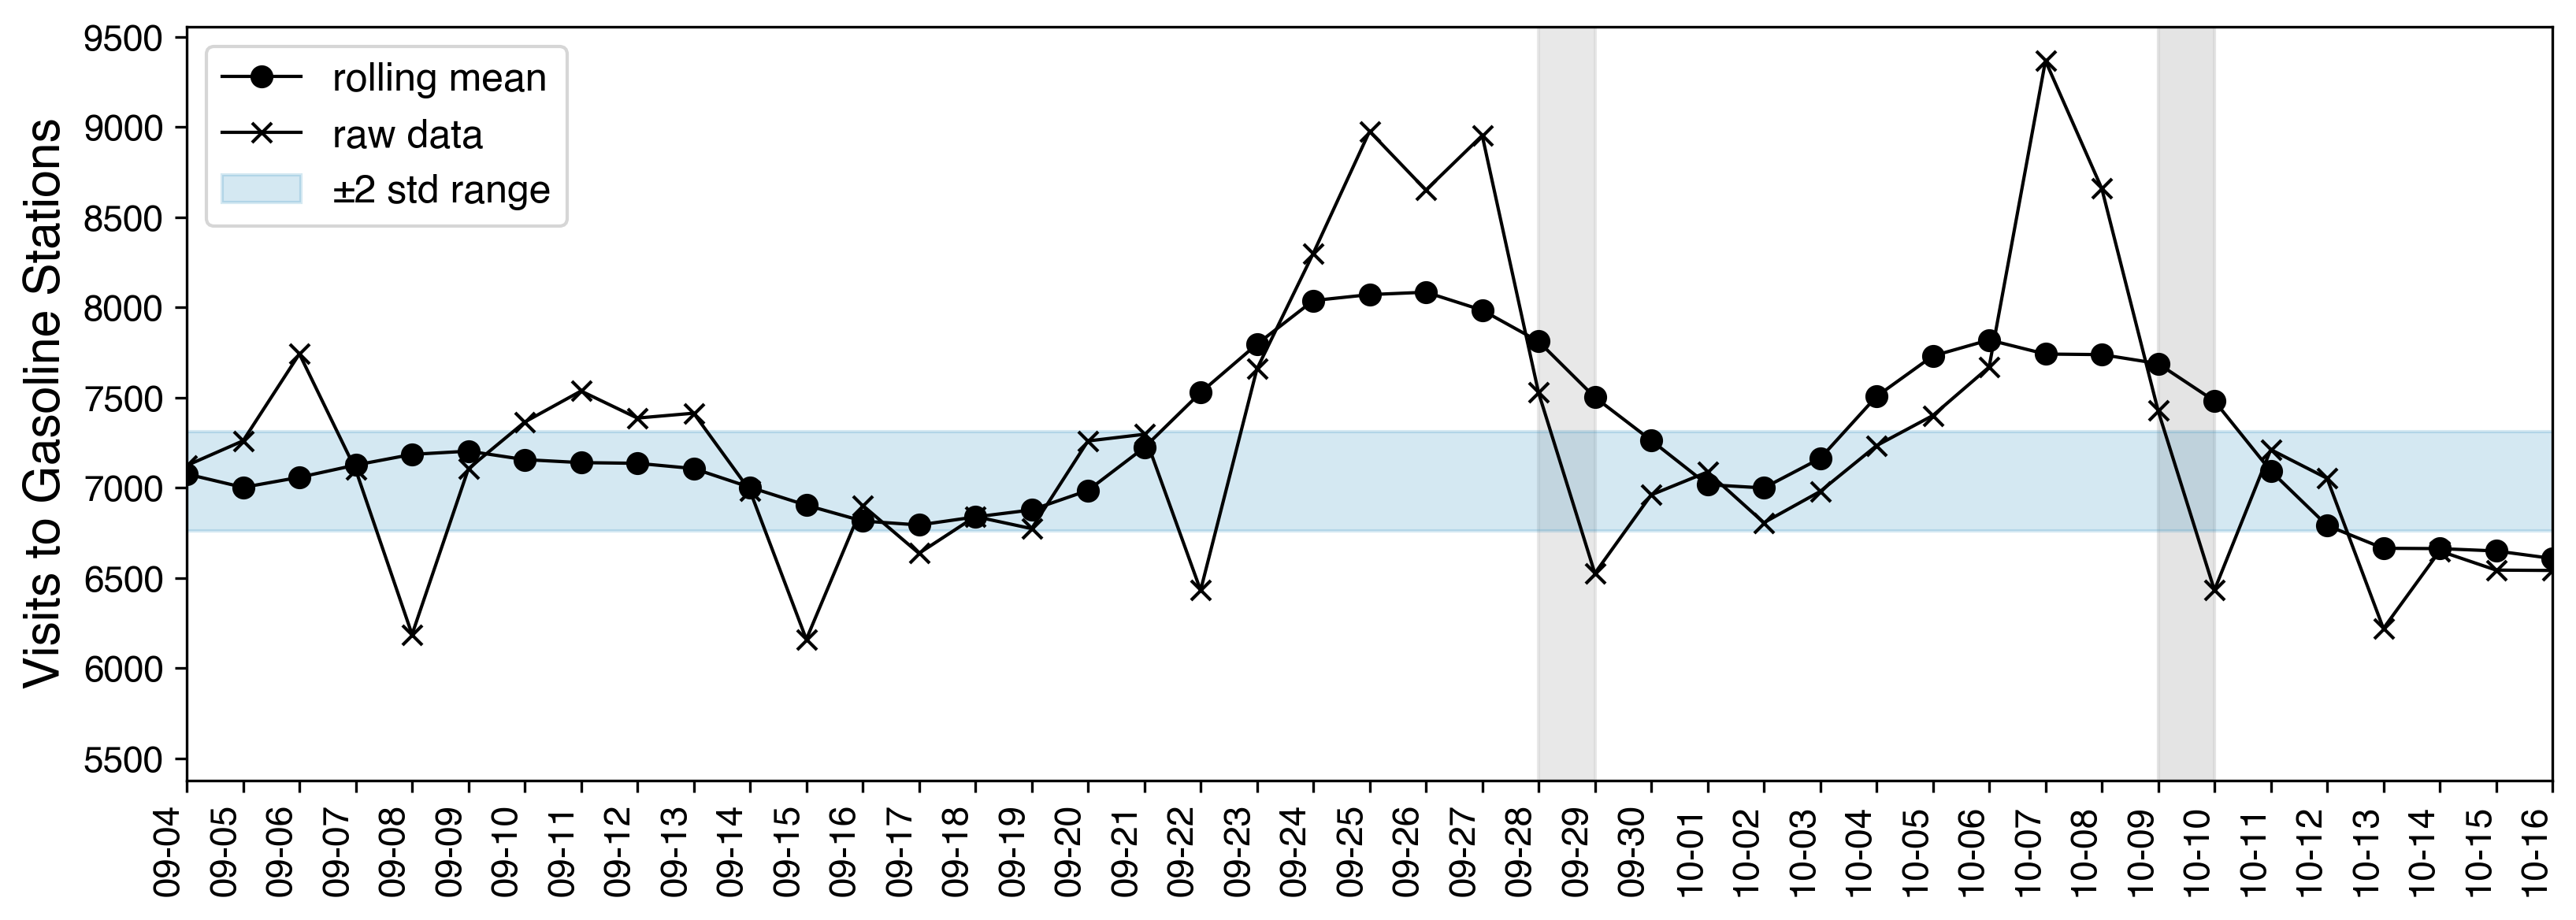

In [13]:
start_date = v_gas.index.min()
end_date = v_gas.index.max()

saturdays = pd.date_range(start=start_date, end=end_date, freq='W-SAT')


plt.rcParams['font.family'] = 'Helvetica'  
plt.figure(figsize=(11, 4),dpi=300)
plt.plot(v_gas.index, v_gas['Gasoline Stations'], marker='o', label='rolling mean',color='black',linewidth=1)
plt.plot(v_gas_raw.index, v_gas_raw['Gasoline Stations'], marker='x', label='raw data',color='black',linewidth=1)
plt.ylabel('Visits to Gasoline Stations', fontsize=15)

plt.axvspan(pd.Timestamp("2024-09-28"), pd.Timestamp("2024-09-29"), color='lightgray', alpha=0.5)
plt.axvspan(pd.Timestamp("2024-10-09"), pd.Timestamp("2024-10-10"), color='lightgray', alpha=0.6)


base_gas = base_roll['Gasoline Stations']
upper = base_gas.mean() + 2 * base_gas.std()
lower = base_gas.mean() - 2 * base_gas.std()
plt.fill_between(v_gas.index, lower, upper, color='#2b8cbe', alpha=0.2, label='±2 std range')

plt.xlim(pd.Timestamp(start_date), pd.Timestamp('2024-10-16'))

plt.gca().xaxis.set_major_locator(mdates.DayLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.gcf().autofmt_xdate()
plt.xticks(rotation=90)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.legend(fontsize=12)

plt.tight_layout()
plt.show()


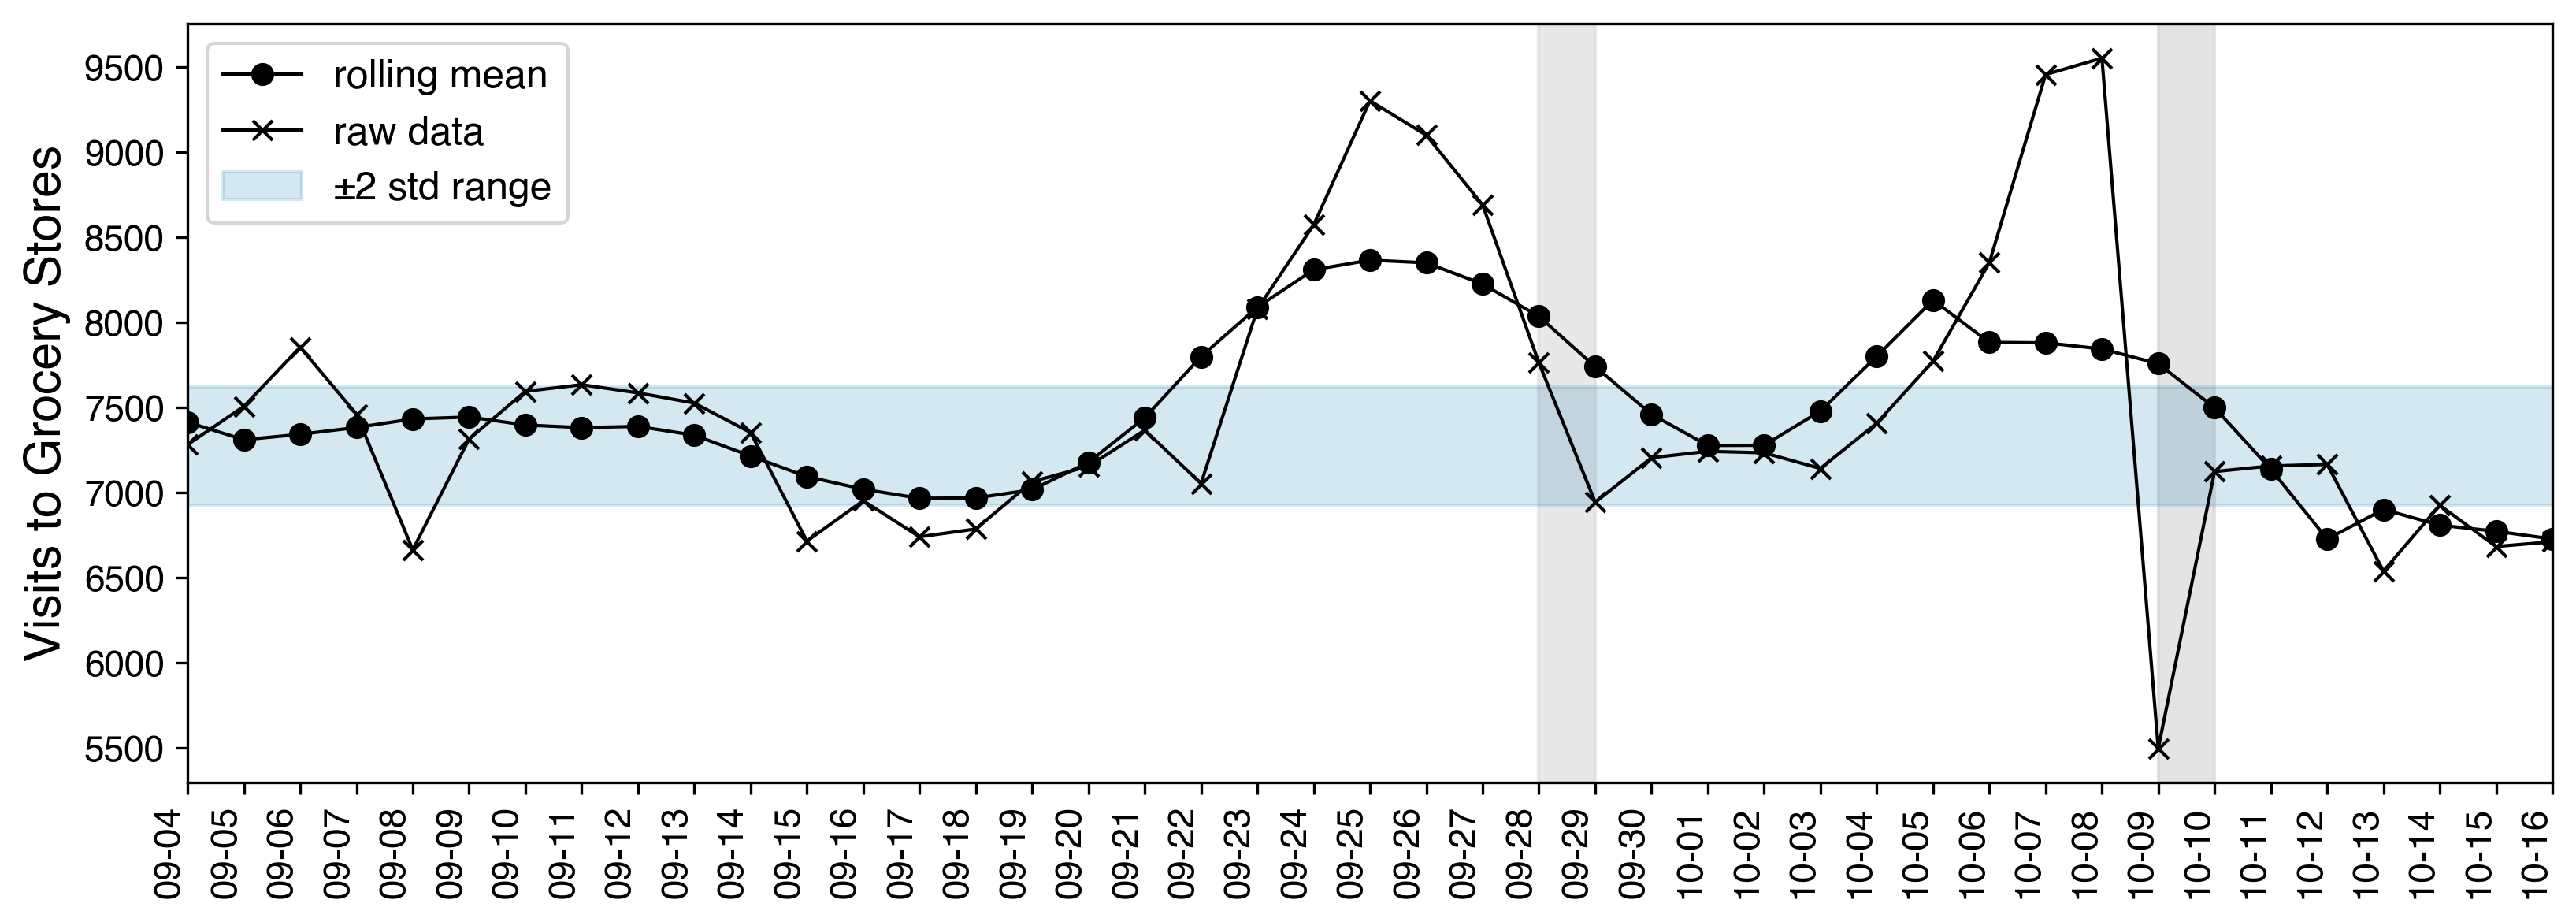

In [14]:
start_date = v_grs.index.min()
end_date = v_grs.index.max()

saturdays = pd.date_range(start=start_date, end=end_date, freq='W-SAT')


plt.rcParams['font.family'] = 'Helvetica' 
plt.figure(figsize=(11, 4),dpi=300)
plt.plot(v_grs.index, v_grs['Grocery Stores'], marker='o', label='rolling mean',color='black',linewidth=1)
plt.plot(v_grs_raw.index, v_grs_raw['Grocery Stores'], marker='x', label='raw data',color='black',linewidth=1)

plt.ylabel('Visits to Grocery Stores', fontsize=15)


plt.axvspan(pd.Timestamp("2024-09-28"), pd.Timestamp("2024-09-29"), color='lightgray', alpha=0.5)
plt.axvspan(pd.Timestamp("2024-10-09"), pd.Timestamp("2024-10-10"), color='lightgray', alpha=0.6)


base_gas = base_roll['Grocery Stores']
upper = base_gas.mean() + 2 * base_gas.std()
lower = base_gas.mean() - 2 * base_gas.std()
plt.fill_between(v_grs.index, lower, upper, color='#2b8cbe', alpha=0.2, label='±2 std range')
plt.xlim(pd.Timestamp(start_date), pd.Timestamp('2024-10-16'))

plt.gca().xaxis.set_major_locator(mdates.DayLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.gcf().autofmt_xdate()
plt.xticks(rotation=90)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.legend(fontsize=12)

plt.tight_layout()
plt.show()


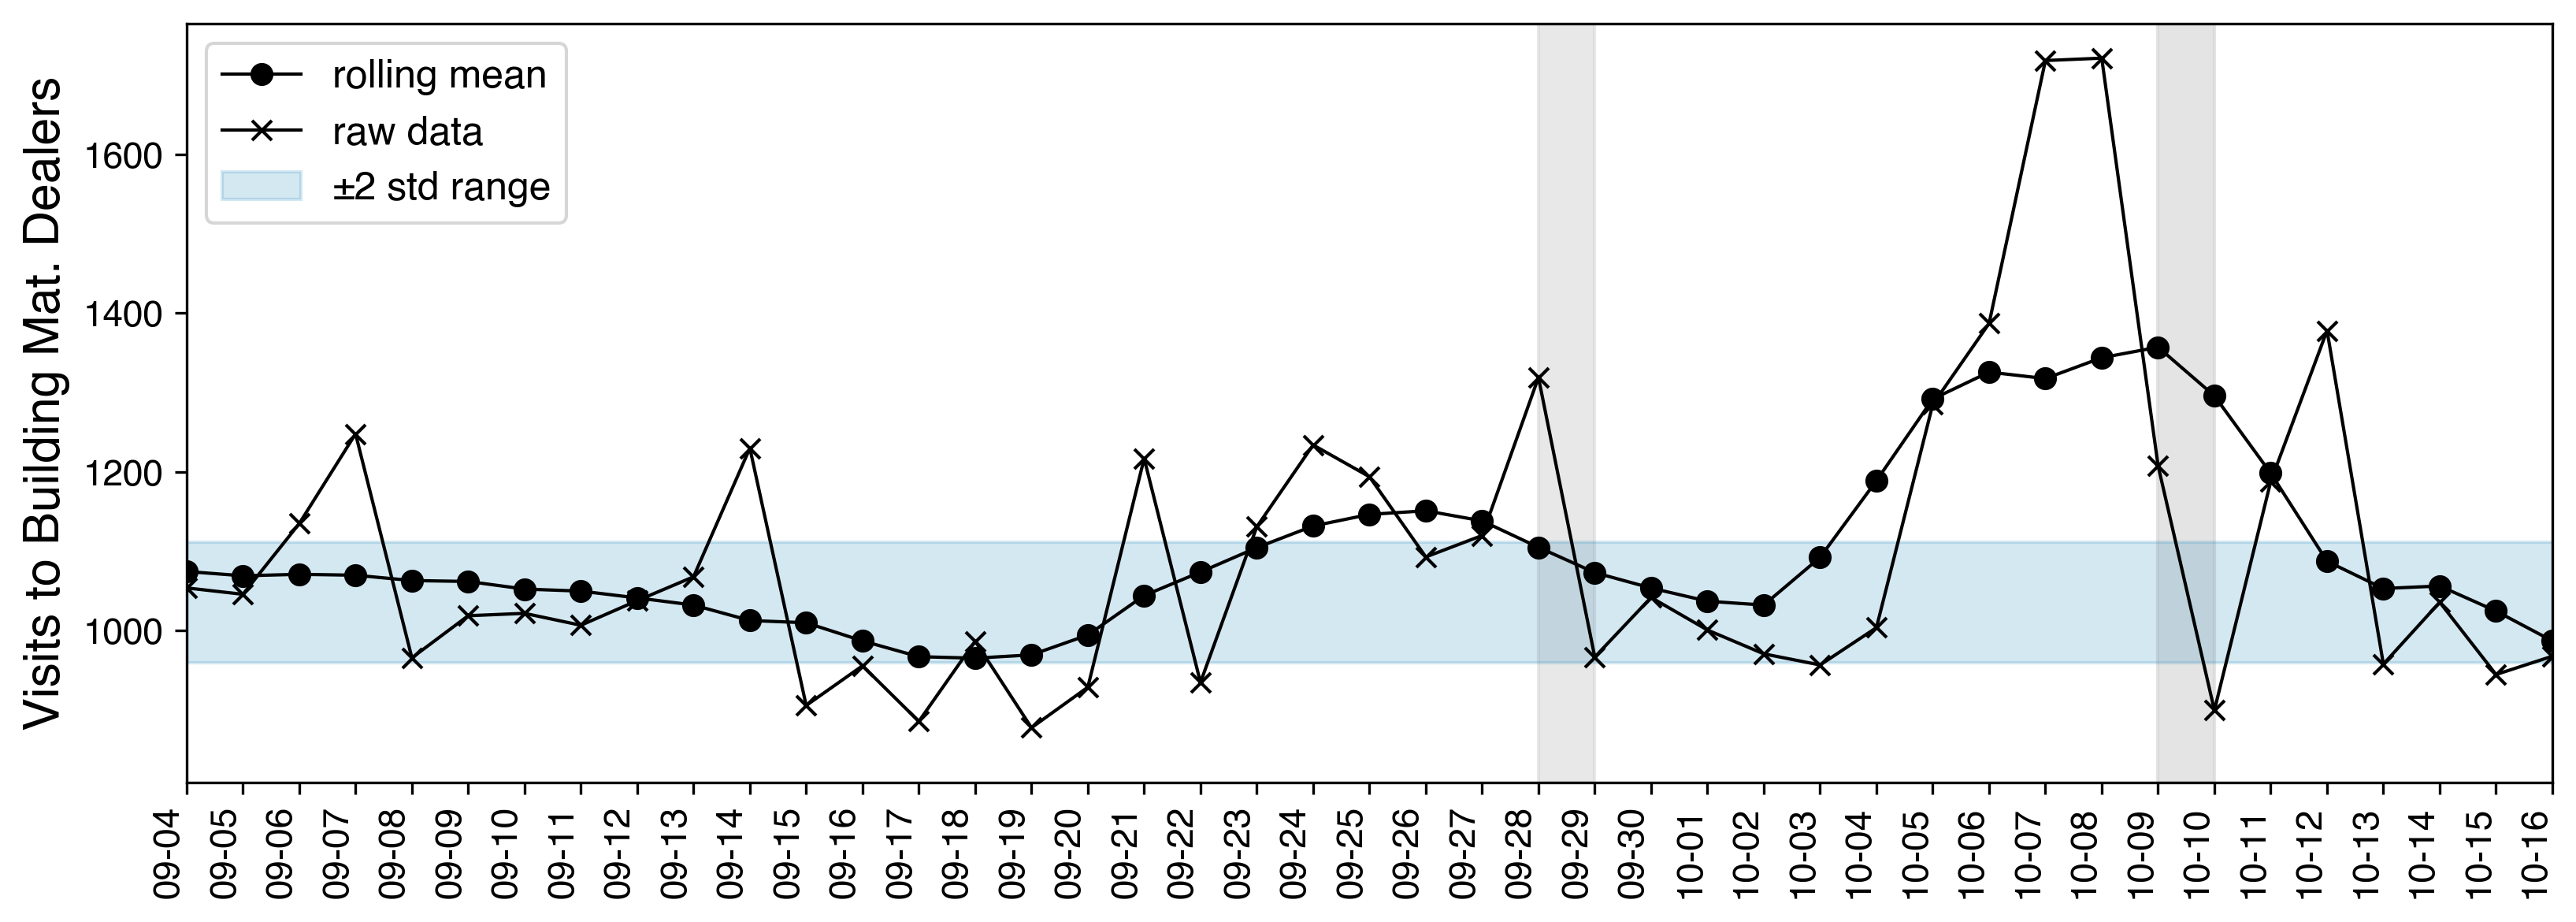

In [15]:
start_date = v_bd.index.min()
end_date = v_bd.index.max()

saturdays = pd.date_range(start=start_date, end=end_date, freq='W-SAT')


plt.rcParams['font.family'] = 'Helvetica'  
plt.figure(figsize=(11, 4),dpi=300)
plt.plot(v_bd.index, v_bd['Building Material and Supplies Dealers'], marker='o', label='rolling mean',color='black',linewidth=1)
plt.plot(v_bd_raw.index, v_bd_raw['Building Material and Supplies Dealers'], marker='x', label='raw data',color='black',linewidth=1)

plt.ylabel('Visits to Building Mat. Dealers', fontsize=15)

plt.axvspan(pd.Timestamp("2024-09-28"), pd.Timestamp("2024-09-29"), color='lightgray', alpha=0.5)
plt.axvspan(pd.Timestamp("2024-10-09"), pd.Timestamp("2024-10-10"), color='lightgray', alpha=0.6)



base_gas = base_roll['Building Material and Supplies Dealers']
upper = base_gas.mean() + 2 * base_gas.std()
lower = base_gas.mean() - 2 * base_gas.std()
plt.fill_between(v_bd.index, lower, upper, color='#2b8cbe', alpha=0.2, label='±2 std range')

plt.xlim(pd.Timestamp(start_date), pd.Timestamp('2024-10-16'))

plt.gca().xaxis.set_major_locator(mdates.DayLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.gcf().autofmt_xdate()
plt.xticks(rotation=90)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)


plt.legend(fontsize=12)

plt.tight_layout()
plt.show()
